# 05_02 · Modelos Afinados — CNC Mill Tool Wear

**Hueco que cubre este notebook:** la cadena CNC se cortaba en `04_02_Evaluación` —
nunca se afinaba ni se guardaba un modelo. El notebook `07_Sistema_Industrial` y la
memoria referencian un `models/cnc_model.pkl` (modelo de Capa 2 reentrenable en planta)
que hasta ahora no existía. Aquí se afina, evalúa y guarda.

### Honestidad estadística por delante
- Solo hay **18 experimentos** (10 worn / 8 unworn). Toda la evaluación es **LOO-CV**
  con el preprocesado completo dentro del `Pipeline` (sin leakage).
- El **baseline trivial** ("predecir siempre worn") da **F1 = 0.714**. Cualquier modelo
  que no lo supere claramente no aporta nada.


In [1]:
import sys; sys.path.insert(0, '../../src')
import warnings; warnings.filterwarnings('ignore')
import pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, roc_auc_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

from paths import PROCESSED as PROC_DIR, MODELS as MODEL_DIR
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(PROC_DIR, 'cnc_aggregated.csv'))
meta = ['experiment', 'material', 'tool_condition', 'target']
feat_cols = [c for c in df.columns if c not in meta]
X = df[feat_cols].fillna(0).values
y = df['target'].values
loo = LeaveOneOut()

f1_trivial = f1_score(y, np.ones_like(y))
print(f'Experimentos: {len(df)} | Features: {len(feat_cols)}')
print(f'Worn: {y.sum()} | Unworn: {(y==0).sum()}')
print(f'Baseline trivial (todo worn): F1 = {f1_trivial:.3f}  ← listón mínimo')


Experimentos: 18 | Features: 183
Worn: 10 | Unworn: 8
Baseline trivial (todo worn): F1 = 0.714  ← listón mínimo


## 1. ¿Ayuda la selección de features?

En el dataset KIT (notebook `05_03`) la selección de features mejoraba el modelo.
Comprobamos si aquí pasa lo mismo antes de asumirlo.


In [2]:
def make_pipe_sel(clf, k):
    """Pipeline con SelectKBest — todo se ajusta dentro de cada fold del LOO."""
    return Pipeline([
        ('var', VarianceThreshold(threshold=0.0)),
        ('sel', SelectKBest(f_classif, k=k)),
        ('sc',  StandardScaler()),
        ('clf', clf),
    ])

def make_pipe(clf):
    """Pipeline sin selección (todas las features)."""
    return Pipeline([
        ('var', VarianceThreshold(threshold=0.0)),
        ('sc',  StandardScaler()),
        ('clf', clf),
    ])

def loo_scores(pipe):
    yp = cross_val_predict(pipe, X, y, cv=loo)
    pr = cross_val_predict(pipe, X, y, cv=loo, method='predict_proba')[:, 1]
    return f1_score(y, yp, zero_division=0), roc_auc_score(y, pr)

rf_ref = lambda: RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                        random_state=42, n_jobs=-1)

rows = []
for k in [5, 10, 20, 30]:
    f1, auc = loo_scores(make_pipe_sel(rf_ref(), k=k))
    rows.append({'config': f'SelectKBest k={k}', 'F1': round(f1, 3), 'AUC': round(auc, 3)})
f1, auc = loo_scores(make_pipe(rf_ref()))
rows.append({'config': f'Sin selección ({len(feat_cols)} feat.)', 'F1': round(f1, 3), 'AUC': round(auc, 3)})

sel_df = pd.DataFrame(rows).set_index('config')
print(sel_df.to_string())
print('\n→ Conclusión: al contrario que en KIT, aquí la selección de features EMPEORA')
print('  (AUC < 0.5 con k pequeño). Con 18 muestras el F-score univariante de cada fold')
print('  es demasiado inestable. Seguimos con todas las features.')


                              F1    AUC
config                                 
SelectKBest k=5            0.455  0.163
SelectKBest k=10           0.455  0.181
SelectKBest k=20           0.500  0.219
SelectKBest k=30           0.500  0.244
Sin selección (183 feat.)  0.692  0.413

→ Conclusión: al contrario que en KIT, aquí la selección de features EMPEORA
  (AUC < 0.5 con k pequeño). Con 18 muestras el F-score univariante de cada fold
  es demasiado inestable. Seguimos con todas las features.


## 2. Comparativa de familias de modelos

Todas las features, pipeline completo dentro del LOO.


In [3]:
candidates = {
    'RF n=200':            RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                  random_state=42, n_jobs=-1),
    'RF n=500 d=5':        RandomForestClassifier(n_estimators=500, max_depth=5,
                                                  class_weight='balanced', random_state=42, n_jobs=-1),
    'GB n=100':            GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM rbf C=1':         SVC(class_weight='balanced', probability=True, random_state=42),
    'SVM linear C=0.1':    SVC(kernel='linear', C=0.1, class_weight='balanced',
                               probability=True, random_state=42),
    'LogReg C=0.01':       LogisticRegression(C=0.01, class_weight='balanced', max_iter=2000),
}

rows = []
for name, clf in candidates.items():
    f1, auc = loo_scores(make_pipe(clf))
    rows.append({'Modelo': name, 'F1': round(f1, 3), 'AUC': round(auc, 3)})

fam_df = pd.DataFrame(rows).set_index('Modelo').sort_values('F1', ascending=False)
print(fam_df.to_string())
print(f'\nBaseline trivial: F1={f1_trivial:.3f}')
print('→ Solo GradientBoosting supera al baseline trivial. RF, SVM y LogReg quedan')
print('  por debajo: con 18 muestras y 183 features memorizan ruido.')


                     F1    AUC
Modelo                        
GB n=100          0.783  0.688
RF n=200          0.692  0.413
RF n=500 d=5      0.667  0.513
SVM linear C=0.1  0.609  0.263
SVM rbf C=1       0.600  0.225
LogReg C=0.01     0.545  0.512

Baseline trivial: F1=0.714
→ Solo GradientBoosting supera al baseline trivial. RF, SVM y LogReg quedan
  por debajo: con 18 muestras y 183 features memorizan ruido.


## 3. Grid fino — GradientBoosting

La única familia competitiva. La intuición clave con n=18 es **regularizar fuerte**:
probamos `max_depth=1` (decision stumps), learning rates bajos y subsampling.


In [4]:
rows = []
for n in [30, 50, 100, 200]:
    for lr in [0.03, 0.05, 0.1, 0.2]:
        for d in [1, 2, 3]:
            for ss in [0.8, 1.0]:
                clf = GradientBoostingClassifier(n_estimators=n, learning_rate=lr,
                                                 max_depth=d, subsample=ss, random_state=42)
                f1, auc = loo_scores(make_pipe(clf))
                rows.append({'n_estimators': n, 'learning_rate': lr, 'max_depth': d,
                             'subsample': ss, 'F1': round(f1, 3), 'AUC': round(auc, 3)})

gb_df = pd.DataFrame(rows).sort_values(['F1', 'AUC'], ascending=False)
print('Top 10 configuraciones:')
print(gb_df.head(10).to_string(index=False))
print('\n→ TODO el top-10 usa max_depth=1 (stumps): la regularización fuerte es lo que')
print('  funciona con tan pocas muestras. Los árboles profundos sobreajustan.')


Top 10 configuraciones:
 n_estimators  learning_rate  max_depth  subsample    F1   AUC
          200           0.20          1        1.0 0.909 0.850
           50           0.10          1        1.0 0.870 0.838
          100           0.10          1        1.0 0.870 0.838
          200           0.10          1        1.0 0.870 0.825
          100           0.05          1        1.0 0.870 0.812
          100           0.20          1        1.0 0.870 0.812
          200           0.03          1        1.0 0.870 0.812
          200           0.05          1        1.0 0.870 0.812
           50           0.20          1        1.0 0.870 0.800
           30           0.20          1        1.0 0.870 0.775

→ TODO el top-10 usa max_depth=1 (stumps): la regularización fuerte es lo que
  funciona con tan pocas muestras. Los árboles profundos sobreajustan.


## 4. Evaluación detallada del mejor modelo


Mejor configuración: {'n_estimators': 200, 'learning_rate': 0.2, 'max_depth': 1, 'subsample': 1.0, 'random_state': 42}

              precision    recall  f1-score   support

      Unworn       1.00      0.75      0.86         8
        Worn       0.83      1.00      0.91        10

    accuracy                           0.89        18
   macro avg       0.92      0.88      0.88        18
weighted avg       0.91      0.89      0.89        18

ROC-AUC: 0.850


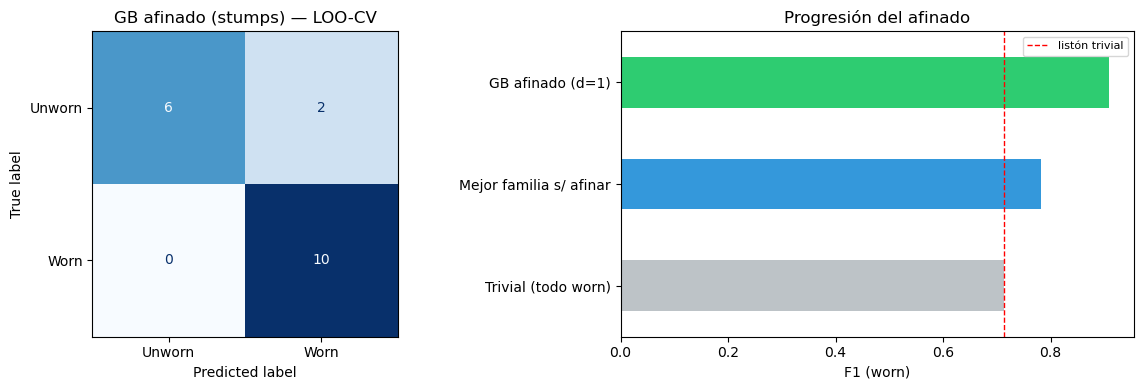

 Exp   Real   Pred  P(worn)
   1   Unwr   Unwr    0.034 ✓
   2   Unwr   Unwr    0.000 ✓
   3   Unwr   Unwr    0.000 ✓
   4   Unwr   Worn    1.000 ✗
   5   Unwr   Worn    1.000 ✗
   6   Worn   Worn    0.756 ✓
   7   Worn   Worn    1.000 ✓
   8   Worn   Worn    1.000 ✓
   9   Worn   Worn    1.000 ✓
  10   Worn   Worn    1.000 ✓
  11   Unwr   Unwr    0.273 ✓
  12   Unwr   Unwr    0.000 ✓
  13   Worn   Worn    1.000 ✓
  14   Worn   Worn    0.999 ✓
  15   Worn   Worn    1.000 ✓
  16   Worn   Worn    0.984 ✓
  17   Unwr   Unwr    0.000 ✓
  18   Worn   Worn    1.000 ✓


In [5]:
best = gb_df.iloc[0]
best_params = {
    'n_estimators':  int(best['n_estimators']),
    'learning_rate': float(best['learning_rate']),
    'max_depth':     int(best['max_depth']),
    'subsample':     float(best['subsample']),
    'random_state':  42,
}
print(f'Mejor configuración: {best_params}')

best_pipe = make_pipe(GradientBoostingClassifier(**best_params))
yp = cross_val_predict(best_pipe, X, y, cv=loo)
pr = cross_val_predict(best_pipe, X, y, cv=loo, method='predict_proba')[:, 1]

print()
print(classification_report(y, yp, target_names=['Unworn', 'Worn']))
print(f'ROC-AUC: {roc_auc_score(y, pr):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y, yp)
ConfusionMatrixDisplay(cm, display_labels=['Unworn', 'Worn']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('GB afinado (stumps) — LOO-CV')

comp = pd.Series({
    'Trivial (todo worn)': f1_trivial,
    'Mejor familia s/ afinar': fam_df['F1'].max(),
    'GB afinado (d=1)': f1_score(y, yp, zero_division=0),
})
comp.plot(kind='barh', ax=axes[1], color=['#bdc3c7', '#3498db', '#2ecc71'])
axes[1].axvline(f1_trivial, color='red', ls='--', lw=1, label='listón trivial')
axes[1].set_xlabel('F1 (worn)')
axes[1].set_title('Progresión del afinado')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

# Detalle experimento a experimento
print(f'{"Exp":>4} {"Real":>6} {"Pred":>6} {"P(worn)":>8}')
for exp, real, pred, p in zip(df['experiment'], y, yp, pr):
    ok = '✓' if real == pred else '✗'
    print(f'{exp:>4} {"Worn" if real else "Unwr":>6} {"Worn" if pred else "Unwr":>6} {p:>8.3f} {ok}')


## 5. Construcción del artefacto

La construcción y guardado de `models/cnc_model.pkl` vive en
**`06_MODELOS_FINALES/06_02_Modelo_Final_Capa2_Mecanica`** — este notebook es solo
experimentación. Si el grid de la sección 3 encuentra una configuración mejor,
actualiza `CNC_PARAMS` en el 06_02 y re-ejecútalo.


## 6. Conclusiones

- **La selección de features empeora** en CNC (al revés que en KIT): con n=18 el
  ranking univariante por fold es ruido.
- **Solo GradientBoosting con stumps (`max_depth=1`) supera con claridad el baseline
  trivial**: F1≈0.87–0.91 y AUC≈0.85 frente al 0.714 de "todo worn". RF, SVM y LogReg
  no lo superan.
- El margen sobre el trivial es real pero el intervalo de confianza con 18 muestras es
  amplio: **este modelo es un prototipo de cold-start**, no un modelo de producción.
  Su valor está en la arquitectura reentrenable: cada experimento nuevo de planta
  mejora el modelo (`pipeline.fit` con los datos acumulados).
- La configuración elegida se construye y guarda en `06_02_Modelo_Final_Capa2_Mecanica`
  (artefacto: `models/cnc_model.pkl`).
